In [5]:
import torch.cuda
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


import seaborn as sns
import random
import copy
import time

In [6]:
!nvidia-smi

Sat Oct  3 12:08:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.88                 KMD Version: 610.88        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   49C    P0            312W /   60W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [8]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [9]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat"
]

SELECTED_CLASSES = [0, 1, 2, 3, 4]

print("Selected classes:")
for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)

Selected classes:
0 -> T-shirt/top
1 -> Trouser
2 -> Pullover
3 -> Dress
4 -> Coat


In [11]:
transform = transforms.ToTensor()

train_dataset_original = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_original = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Original training samples:", len(train_dataset_original))
print("Original test samples:", len(test_dataset_original))

100.0%
100.0%
100.0%
100.0%

Original training samples: 60000
Original test samples: 10000


In [12]:
X_train_original = train_dataset_original.data.numpy()
y_train_original = train_dataset_original.targets.numpy()

X_test_original = test_dataset_original.data.numpy()
y_test_original = test_dataset_original.targets.numpy()

X_all = np.concatenate([X_train_original, X_test_original], axis=0)

y_all = np.concatenate([y_train_original, y_test_original], axis=0)

print("Combined dataset:", X_all.shape)

Combined dataset: (70000, 28, 28)


In [13]:
mask = np.isin(y_all,SELECTED_CLASSES)

X_selected = X_all[mask]
y_selected_original = y_all[mask]

print("Selected samples:", len(X_selected))

Selected samples: 35000


In [14]:
print("Class distribution:\n")

for cls in SELECTED_CLASSES:
    count = np.sum(y_selected_original == cls)

    print(f"{cls} - {CLASS_NAMES[cls]}: {count}")

Class distribution:

0 - T-shirt/top: 7000
1 - Trouser: 7000
2 - Pullover: 7000
3 - Dress: 7000
4 - Coat: 7000


In [15]:
label_mapping = {
    original_label: new_label
    for new_label, original_label
    in enumerate(SELECTED_CLASSES)
}

y_selected = np.array([
    label_mapping[label]
    for label in y_selected_original
])

print("Label mapping:")
print(label_mapping)

print("\nUnique labels:", np.unique(y_selected))

Label mapping:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

Unique labels: [0 1 2 3 4]


In [16]:
X_selected = X_selected.astype(np.float32) / 255.0

print("Minimum pixel value:", X_selected.min())
print("Maximum pixel value:", X_selected.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [17]:
X_selected = X_selected.reshape(X_selected.shape[0], 784)

print("Dataset shape:", X_selected.shape)

Dataset shape: (35000, 784)


In [18]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_selected,
    y_selected,
    test_size=0.20,
    random_state=SEED,
    stratify=y_selected
)

print("Temporary training set:", X_temp.shape)
print("Test set:", X_test.shape)

Temporary training set: (28000, 784)
Test set: (7000, 784)


In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.20,
    random_state=SEED,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (22400, 784)
Validation: (5600, 784)
Test: (7000, 784)


In [21]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

print(X_train.shape)
print(y_train.shape)

torch.Size([22400, 784])
torch.Size([22400])


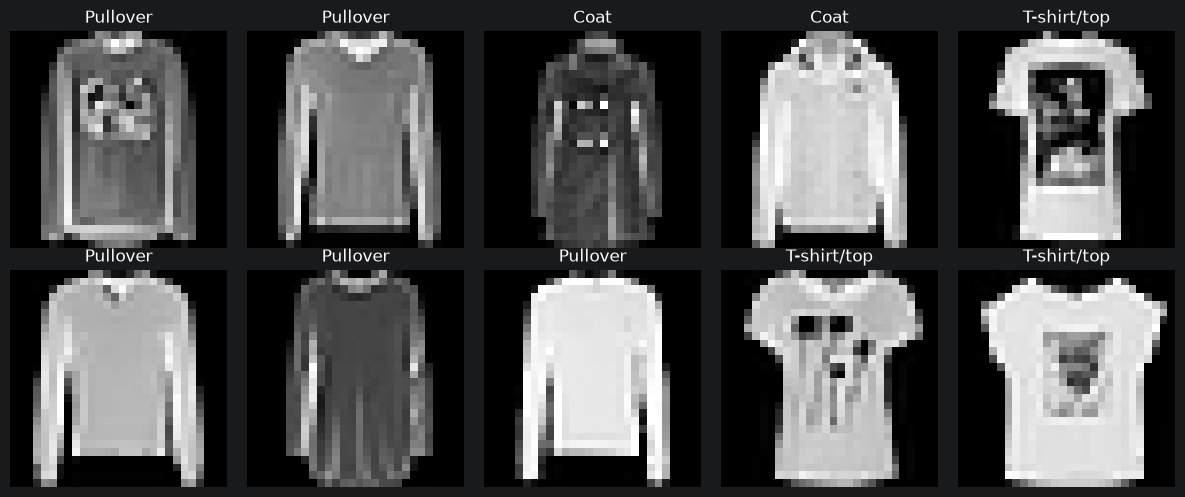

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):

    image = X_train[i].reshape(28, 28)

    ax.imshow(image, cmap="gray")
    ax.set_title(CLASS_NAMES[y_train[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [23]:
class FCNN(nn.Module):

    def __init__(self, hidden_layers):
        super().__init__()

        layers = []

        input_size = 784

        for hidden_size in hidden_layers:

            layers.append(nn.Linear(input_size, hidden_size))

            layers.append(nn.ReLU())

            input_size = hidden_size

        # Output layer
        layers.append(nn.Linear(input_size, 5))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [24]:
ARCHITECTURES = {

    "Architecture 1": [128, 64, 32],
    "Architecture 2": [256, 128, 64, 32],
    "Architecture 3": [256, 128, 64, 32, 16]
}

In [25]:
LEARNING_RATE = 0.001

MOMENTUM = 0.9

RMS_BETA = 0.99
RMS_EPS = 1e-8

ADAM_BETA1 = 0.9
ADAM_BETA2 = 0.999
ADAM_EPS = 1e-8

CONVERGENCE_THRESHOLD = 1e-4

MAX_EPOCHS = 100

In [26]:
criterion = nn.CrossEntropyLoss()

In [27]:
def create_initial_state(hidden_layers):

    torch.manual_seed(SEED)

    model = FCNN(hidden_layers)

    return copy.deepcopy(model.state_dict())

In [31]:
def calculate_accuracy(model, X, y):

    model.eval()

    with torch.no_grad():

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        predictions = torch.argmax(outputs, dim=1)

        accuracy = (predictions == y).float().mean()

    return accuracy.item() * 100

In [32]:
def get_predictions(model, X):

    model.eval()

    with torch.no_grad():

        X = X.to(device)

        outputs = model(X)

        predictions = torch.argmax(outputs, dim=1)

    return predictions.cpu().numpy()

In [33]:
def sgd_step(model, lr):

    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

In [34]:
def momentum_step(model, velocities, lr, momentum):

    with torch.no_grad():
        for param, velocity in zip(model.parameters(), velocities):

            velocity.mul_(momentum)
            velocity.add_(-lr * param.grad)

            param.add_(velocity)

In [35]:
def rmsprop_step(model, squared_gradients, lr, beta, eps):

    with torch.no_grad():
        for param, sq_grad in zip(model.parameters(), squared_gradients):

            sq_grad.mul_(beta)
            sq_grad.add_((1 - beta) * param.grad.pow(2))

            param -= (lr * param.grad / (torch.sqrt(sq_grad) + eps))

In [36]:
def adam_step(model, first_moment, second_moment, lr, beta1, beta2, eps, step):

    with torch.no_grad():
        for param, m, v in zip(model.parameters(), first_moment, second_moment):

            grad = param.grad
            m.mul_(beta1)
            m.add_((1 - beta1) * grad)

            v.mul_(beta2)
            v.add_((1 - beta2) * grad.pow(2))

            m_hat = (m / (1 - beta1 ** step))
            v_hat = (v / (1 - beta2 ** step))

            param -= (lr * m_hat / (torch.sqrt(v_hat) + eps))

In [37]:
def nag_step(model, velocities, lr, momentum):

    old_parameters = [param.detach().clone() for param in model.parameters()]

    with torch.no_grad():
        for param, velocity in zip(model.parameters(), velocities):
            param.add_(momentum * velocity)

    return old_parameters

In [38]:
def initialize_optimizer_state(model, optimizer_name):

    parameters = list(model.parameters())

    if optimizer_name in ["Momentum", "NAG"]:
        return {"velocity": [torch.zeros_like(p) for p in parameters]}

    elif optimizer_name == "RMSProp":
        return {"squared_gradients": [torch.zeros_like(p) for p in parameters]}

    elif optimizer_name == "Adam":
        return {"first_moment": [torch.zeros_like(p) for p in parameters],
            "second_moment": [torch.zeros_like(p) for p in parameters],
            "step": 0
        }

    return {}

In [39]:
def train_model(hidden_layers, optimizer_name, X_train, y_train, X_val, y_val, max_epochs=100):

    # Create model
    model = FCNN(hidden_layers).to(device)

    # Same initial weights
    initial_state = create_initial_state(hidden_layers)

    model.load_state_dict(initial_state)

    # Optimizer state
    optimizer_state = initialize_optimizer_state(model, optimizer_name)

    # Batch size
    if optimizer_name == "Batch GD":
        batch_size = len(X_train)
    else:
        batch_size = 1

    history = {"errors": [], "train_accuracy": [],"val_accuracy": []}

    previous_error = None

    global_step = 0

    for epoch in range(max_epochs):

        model.train()

        # Shuffle training data
        permutation = torch.randperm(len(X_train))

        epoch_error = 0.0

        # ------------------------------------------------
        # NAG requires a special look-ahead implementation
        # ------------------------------------------------

        for start in range(0, len(X_train), batch_size):

            indices = permutation[start:start + batch_size]

            X_batch = X_train[indices].to(device)
            y_batch = y_train[indices].to(device)

            # NAG look-ahead
            if optimizer_name == "NAG":

                with torch.no_grad():
                    for param, velocity in zip(model.parameters(), optimizer_state["velocity"]):
                        param.add_(MOMENTUM * velocity)

            model.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()

            epoch_error += (loss.item() * len(X_batch))

            # --------------------------------------------
            # Update
            # --------------------------------------------

            if optimizer_name == "SGD":
                sgd_step(model, LEARNING_RATE)

            elif optimizer_name == "Batch GD":
                sgd_step(model, LEARNING_RATE)

            elif optimizer_name == "Momentum":
                momentum_step(model, optimizer_state["velocity"], LEARNING_RATE, MOMENTUM)

            elif optimizer_name == "NAG":

                # Undo look-ahead temporarily
                with torch.no_grad():
                    for param, velocity in zip(model.parameters(), optimizer_state["velocity"]):
                        param.sub_(MOMENTUM * velocity)

                # Update velocity
                with torch.no_grad():
                    for param, velocity in zip(model.parameters(), optimizer_state["velocity"]):
                        velocity.mul_(MOMENTUM)
                        velocity.add_(-LEARNING_RATE * param.grad)
                        param.add_(velocity)

            elif optimizer_name == "RMSProp":
                rmsprop_step(model, optimizer_state["squared_gradients"],
                    LEARNING_RATE,
                    RMS_BETA,
                    RMS_EPS
                )

            elif optimizer_name == "Adam":

                optimizer_state["step"] += 1
                adam_step(model,
                    optimizer_state["first_moment"],
                    optimizer_state["second_moment"],
                    LEARNING_RATE,
                    ADAM_BETA1,
                    ADAM_BETA2,
                    ADAM_EPS,
                    optimizer_state["step"]
                )

            global_step += 1

        # Average error over training samples
        average_error = (epoch_error / len(X_train))

        history["errors"].append(average_error)

        train_accuracy = calculate_accuracy(model, X_train, y_train)
        val_accuracy = calculate_accuracy(model, X_val, y_val)

        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:3d} | "
            f"Error: {average_error:.6f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Val Acc: {val_accuracy:.2f}%"
        )

        # --------------------------------------------
        # Convergence criterion
        # --------------------------------------------

        if previous_error is not None:

            error_difference = abs(average_error - previous_error)

            if (error_difference < CONVERGENCE_THRESHOLD):
                print(f"\nConverged at epoch " f"{epoch + 1}")
                break

        previous_error = average_error

    return model, history

In [40]:
test_model, test_history = train_model(
    hidden_layers=ARCHITECTURES["Architecture 1"],
    optimizer_name="Adam",
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    max_epochs=MAX_EPOCHS
)

Epoch   1 | Error: 0.443985 | Train Acc: 85.94% | Val Acc: 85.66%
Epoch   2 | Error: 0.352300 | Train Acc: 86.34% | Val Acc: 86.87%
Epoch   3 | Error: 0.326790 | Train Acc: 89.64% | Val Acc: 89.34%
Epoch   4 | Error: 0.315093 | Train Acc: 89.56% | Val Acc: 89.46%
Epoch   5 | Error: 0.307175 | Train Acc: 90.76% | Val Acc: 90.36%
Epoch   6 | Error: 0.299112 | Train Acc: 89.79% | Val Acc: 89.46%
Epoch   7 | Error: 0.290802 | Train Acc: 90.72% | Val Acc: 90.05%
Epoch   8 | Error: 0.287660 | Train Acc: 84.13% | Val Acc: 83.59%
Epoch   9 | Error: 0.284633 | Train Acc: 91.01% | Val Acc: 89.91%
Epoch  10 | Error: 0.283598 | Train Acc: 90.60% | Val Acc: 89.45%
Epoch  11 | Error: 0.276092 | Train Acc: 91.37% | Val Acc: 90.32%
Epoch  12 | Error: 0.276736 | Train Acc: 91.12% | Val Acc: 90.05%
Epoch  13 | Error: 0.273116 | Train Acc: 91.28% | Val Acc: 90.04%
Epoch  14 | Error: 0.271264 | Train Acc: 91.50% | Val Acc: 90.39%
Epoch  15 | Error: 0.268472 | Train Acc: 89.45% | Val Acc: 88.55%
Epoch  16 

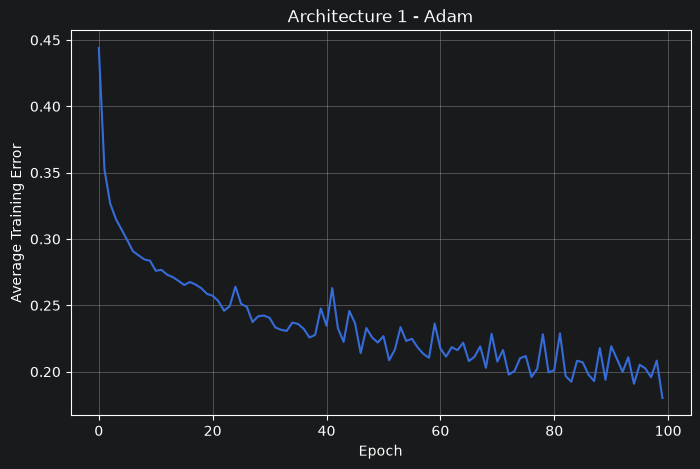

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    test_history["errors"]
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Error")
plt.title(
    "Architecture 1 - Adam"
)

plt.grid(True)
plt.show()

In [42]:
print(
    "Training Accuracy:",
    calculate_accuracy(
        test_model,
        X_train,
        y_train
    )
)

print(
    "Validation Accuracy:",
    calculate_accuracy(
        test_model,
        X_val,
        y_val
    )
)

Training Accuracy: 95.29910683631897
Validation Accuracy: 90.51785469055176


In [43]:
OPTIMIZERS = [
    "SGD",
    "Batch GD",
    "Momentum",
    "NAG",
    "RMSProp",
    "Adam"
]

print(OPTIMIZERS)

['SGD', 'Batch GD', 'Momentum', 'NAG', 'RMSProp', 'Adam']


In [44]:
results = {}

for architecture_name, hidden_layers in ARCHITECTURES.items():

    print("\n")
    print("=" * 70)
    print(architecture_name)
    print("=" * 70)

    results[architecture_name] = {}

    for optimizer_name in OPTIMIZERS:

        print("\n")
        print("-" * 70)
        print(f"{architecture_name} + " f"{optimizer_name}"        )
        print("-" * 70)

        start_time = time.time()

        model, history = train_model(
            hidden_layers=hidden_layers,
            optimizer_name=optimizer_name,
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            max_epochs=MAX_EPOCHS
        )

        training_time = (time.time() - start_time)

        results[architecture_name][optimizer_name] = {
            "model": model,
            "history": history,
            "epochs": len(history["errors"]),
            "train_accuracy": history["train_accuracy"][-1],
            "val_accuracy": history["val_accuracy"][-1],
            "training_time": training_time
        }

        print(f"Training time: " f"{training_time:.2f} seconds")



Architecture 1


----------------------------------------------------------------------
Architecture 1 + SGD
----------------------------------------------------------------------
Epoch   1 | Error: 0.751641 | Train Acc: 84.08% | Val Acc: 84.55%
Epoch   2 | Error: 0.399081 | Train Acc: 87.28% | Val Acc: 87.05%
Epoch   3 | Error: 0.356193 | Train Acc: 87.26% | Val Acc: 87.23%
Epoch   4 | Error: 0.332912 | Train Acc: 89.04% | Val Acc: 89.07%
Epoch   5 | Error: 0.313962 | Train Acc: 89.77% | Val Acc: 89.34%
Epoch   6 | Error: 0.298319 | Train Acc: 90.02% | Val Acc: 89.64%
Epoch   7 | Error: 0.284208 | Train Acc: 90.50% | Val Acc: 90.11%
Epoch   8 | Error: 0.273819 | Train Acc: 90.26% | Val Acc: 89.39%
Epoch   9 | Error: 0.263433 | Train Acc: 90.15% | Val Acc: 89.05%
Epoch  10 | Error: 0.256540 | Train Acc: 91.21% | Val Acc: 90.13%
Epoch  11 | Error: 0.248884 | Train Acc: 91.27% | Val Acc: 90.27%
Epoch  12 | Error: 0.241926 | Train Acc: 90.76% | Val Acc: 89.88%
Epoch  13 | Error: 0.23454

In [45]:
rows = []

for architecture_name in results:

    for optimizer_name in results[architecture_name]:

        result = results[architecture_name][optimizer_name]

        rows.append({
            "Architecture": architecture_name,
            "Optimizer": optimizer_name,
            "Epochs": result["epochs"],
            "Training Accuracy": result["train_accuracy"],
            "Validation Accuracy": result["val_accuracy"],
            "Training Time (sec)": result["training_time"]
        })

results_df = pd.DataFrame(rows)

results_df

,Architecture,Optimizer,Epochs,Training Accuracy,Validation Accuracy,Training Time (sec)
0,Architecture 1,SGD,46,96.482140,91.249996,1352.246899
1,Architecture 1,Batch GD,2,21.089286,20.660715,0.234303
2,Architecture 1,Momentum,44,95.236605,91.232145,1768.288774
3,Architecture 1,NAG,74,95.397323,90.625000,3104.300797
4,Architecture 1,RMSProp,100,53.241068,52.285713,5384.936084
5,Architecture 1,Adam,100,95.299107,90.517855,5669.287770
6,Architecture 2,SGD,57,97.611606,91.410714,1832.009365
7,Architecture 2,Batch GD,2,19.647321,19.499999,0.124965
8,Architecture 2,Momentum,40,93.879461,90.196425,3420.474366
9,Architecture 2,NAG,96,97.508925,92.107141,9502.692192


In [47]:
results_df.style.format({
    "Training Accuracy": "{:.2f}%",
    "Validation Accuracy": "{:.2f}%",
    "Training Time (sec)": "{:.2f}"
})

,Architecture,Optimizer,Epochs,Training Accuracy,Validation Accuracy,Training Time (sec)
0,Architecture 1,SGD,46,96.48%,91.25%,1352.25
1,Architecture 1,Batch GD,2,21.09%,20.66%,0.23
2,Architecture 1,Momentum,44,95.24%,91.23%,1768.29
3,Architecture 1,NAG,74,95.40%,90.62%,3104.30
4,Architecture 1,RMSProp,100,53.24%,52.29%,5384.94
5,Architecture 1,Adam,100,95.30%,90.52%,5669.29
6,Architecture 2,SGD,57,97.61%,91.41%,1832.01
7,Architecture 2,Batch GD,2,19.65%,19.50%,0.12
8,Architecture 2,Momentum,40,93.88%,90.20%,3420.47
9,Architecture 2,NAG,96,97.51%,92.11%,9502.69


In [48]:
epochs_table = results_df.pivot(
    index="Architecture",
    columns="Optimizer",
    values="Epochs"
)

epochs_table

Optimizer,Adam,Batch GD,Momentum,NAG,RMSProp,SGD
Architecture,,,,,,
Architecture 1,100,2,44,74,100,46
Architecture 2,100,2,40,96,100,57
Architecture 3,100,2,27,100,53,61


In [49]:
train_accuracy_table = results_df.pivot(
    index="Architecture",
    columns="Optimizer",
    values="Training Accuracy"
)

train_accuracy_table

Optimizer,Adam,Batch GD,Momentum,NAG,RMSProp,SGD
Architecture,,,,,,
Architecture 1,95.299107,21.089286,95.236605,95.397323,53.241068,96.482140
Architecture 2,94.803572,19.647321,93.879461,97.508925,40.665179,97.611606
Architecture 3,75.473213,20.000000,93.357140,97.191966,20.000000,97.491068


In [50]:
val_accuracy_table = results_df.pivot(
    index="Architecture",
    columns="Optimizer",
    values="Validation Accuracy"
)

val_accuracy_table

Optimizer,Adam,Batch GD,Momentum,NAG,RMSProp,SGD
Architecture,,,,,,
Architecture 1,90.517855,20.660715,91.232145,90.625000,52.285713,91.249996
Architecture 2,90.535712,19.499999,90.196425,92.107141,40.035713,91.410714
Architecture 3,74.232143,20.000000,90.892857,91.107142,20.000000,91.392857


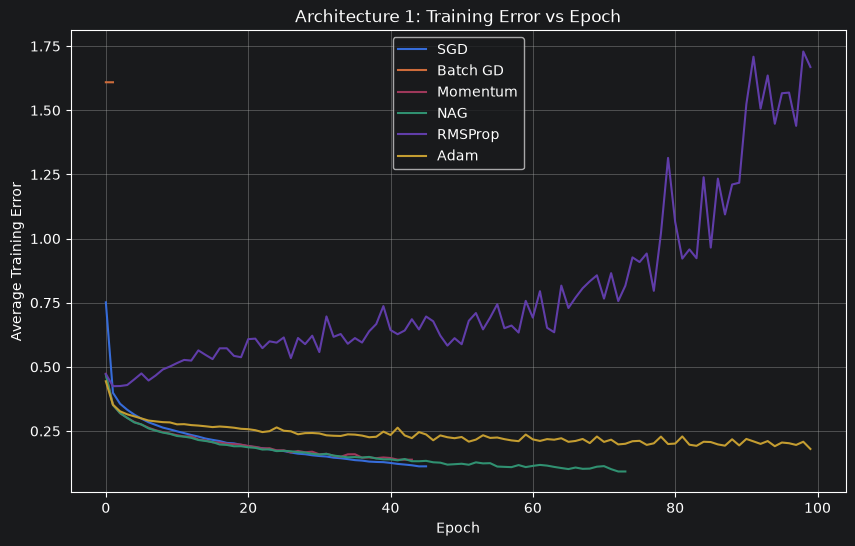

In [51]:
plt.figure(figsize=(10, 6))

architecture_name = "Architecture 1"

for optimizer_name in OPTIMIZERS:

    history = results[architecture_name][optimizer_name]["history"]

    plt.plot(
        history["errors"],
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Average Training Error")
plt.title("Architecture 1: Training Error vs Epoch")

plt.legend()
plt.grid(True)

plt.show()

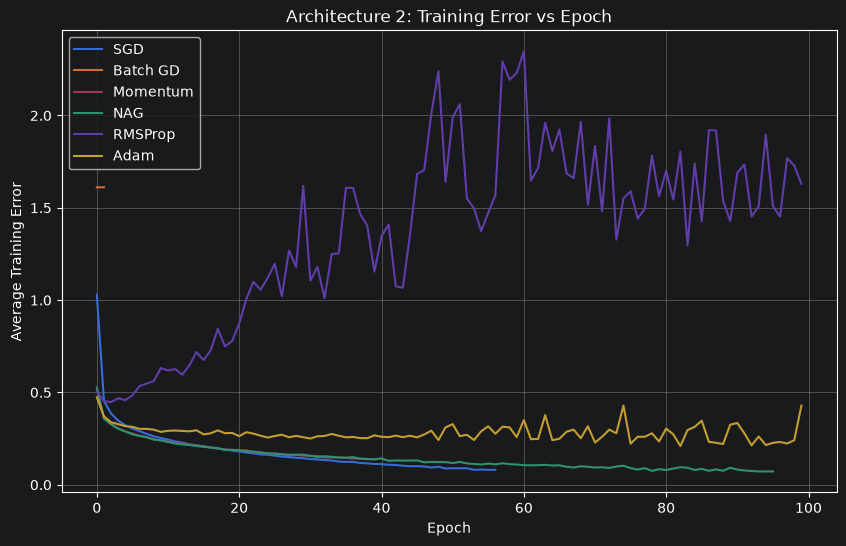

In [52]:
plt.figure(figsize=(10, 6))

architecture_name = "Architecture 2"

for optimizer_name in OPTIMIZERS:

    history = results[architecture_name][optimizer_name]["history"]

    plt.plot(
        history["errors"],
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Average Training Error")
plt.title("Architecture 2: Training Error vs Epoch")

plt.legend()
plt.grid(True)

plt.show()

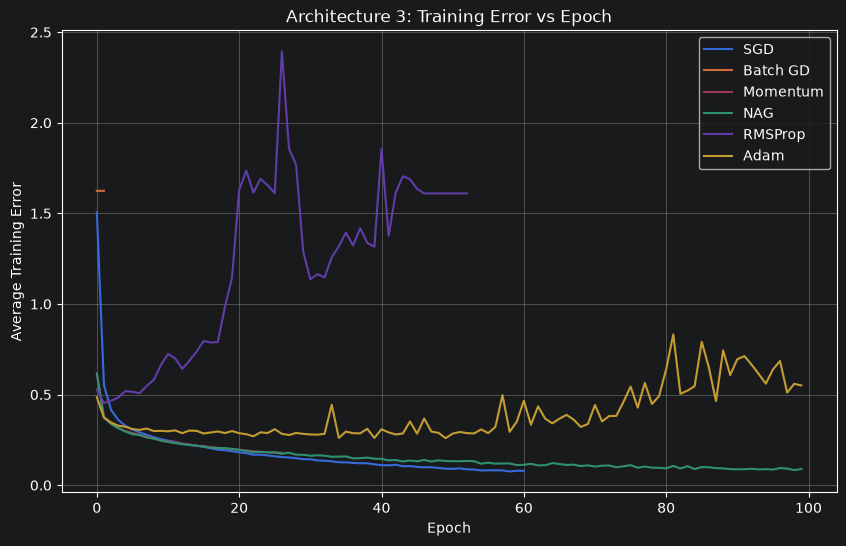

In [53]:
plt.figure(figsize=(10, 6))

architecture_name = "Architecture 3"

for optimizer_name in OPTIMIZERS:

    history = results[architecture_name][optimizer_name]["history"]

    plt.plot(
        history["errors"],
        label=optimizer_name
    )

plt.xlabel("Epoch")
plt.ylabel("Average Training Error")
plt.title("Architecture 3: Training Error vs Epoch")

plt.legend()
plt.grid(True)

plt.show()

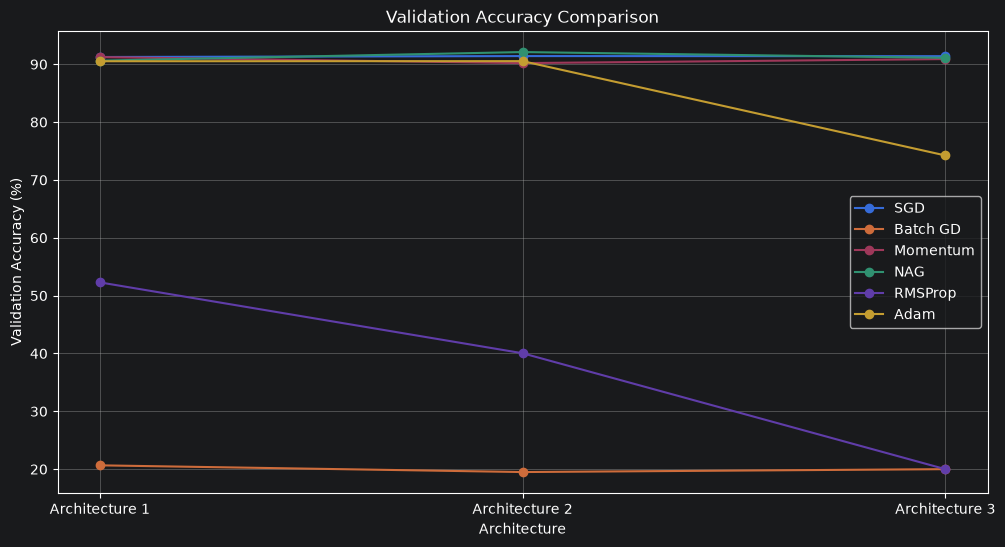

In [54]:
plt.figure(figsize=(12, 6))

for optimizer_name in OPTIMIZERS:

    values = []

    for architecture_name in ARCHITECTURES:

        values.append(results[architecture_name][optimizer_name]["val_accuracy"])

    plt.plot(
        list(ARCHITECTURES.keys()),
        values,
        marker="o",
        label=optimizer_name
    )

plt.xlabel("Architecture")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [55]:
best_result = results_df.loc[results_df["Validation Accuracy"].idxmax()]

best_result

Architecture           Architecture 2
Optimizer                         NAG
Epochs                             96
Training Accuracy           97.508925
Validation Accuracy         92.107141
Training Time (sec)       9502.692192
Name: 9, dtype: object

In [56]:
best_architecture = best_result["Architecture"]
best_optimizer = best_result["Optimizer"]
best_model = results[best_architecture][best_optimizer]["model"]

print("Best Architecture:", best_architecture)
print("Optimizer:", best_optimizer)
print("Validation Accuracy:", best_result["Validation Accuracy"])

Best Architecture: Architecture 2
Optimizer: NAG
Validation Accuracy: 92.10714101791382


In [57]:
final_train_accuracy = calculate_accuracy(best_model, X_train, y_train)

print(f"Training Accuracy: " f"{final_train_accuracy:.2f}%")

Training Accuracy: 97.51%


In [58]:
final_test_accuracy = calculate_accuracy(best_model, X_test, y_test)

print(f"Test Accuracy: " f"{final_test_accuracy:.2f}%")

Test Accuracy: 91.80%


In [59]:
train_predictions = get_predictions(best_model, X_train)

print("Number of training predictions:", len(train_predictions))

Number of training predictions: 22400


In [60]:
test_predictions = get_predictions(best_model, X_test)

print("Number of test predictions:", len(test_predictions))

Number of test predictions: 7000


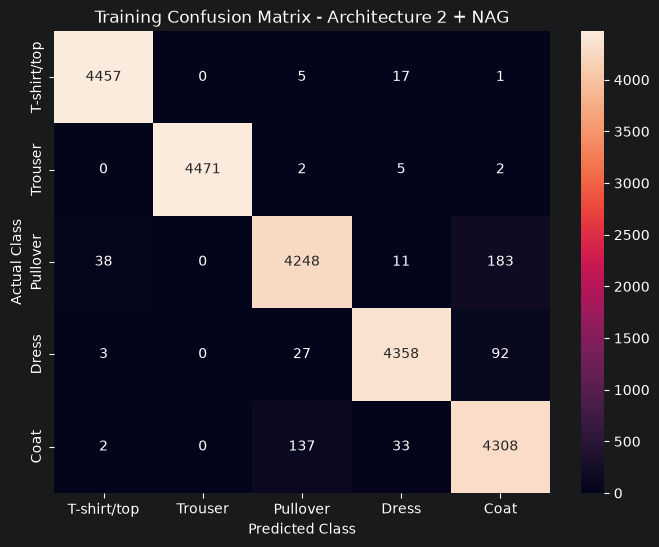

In [61]:
train_cm = confusion_matrix(y_train.numpy(), train_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    train_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    f"Training Confusion Matrix - "
    f"{best_architecture} + {best_optimizer}"
)

plt.show()

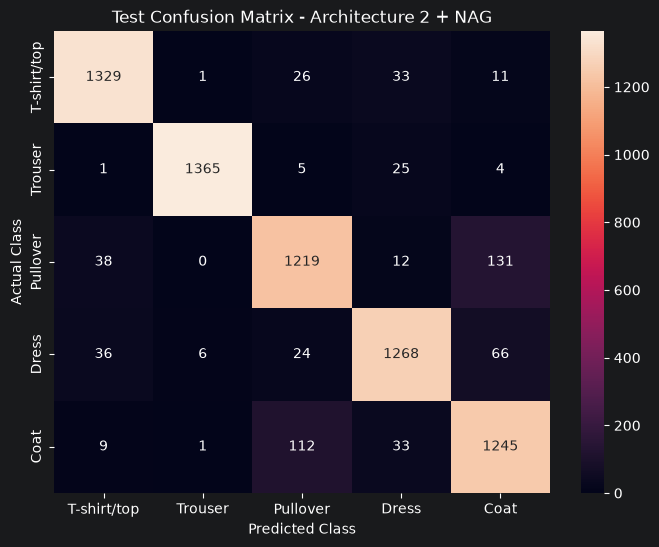

In [62]:
test_cm = confusion_matrix(y_test.numpy(), test_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    f"Test Confusion Matrix - "
    f"{best_architecture} + {best_optimizer}"
)

plt.show()

In [63]:
print(
    classification_report(
        y_test.numpy(),
        test_predictions,
        target_names=CLASS_NAMES
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.94      0.95      0.94      1400
     Trouser       0.99      0.97      0.98      1400
    Pullover       0.88      0.87      0.88      1400
       Dress       0.92      0.91      0.92      1400
        Coat       0.85      0.89      0.87      1400

    accuracy                           0.92      7000
   macro avg       0.92      0.92      0.92      7000
weighted avg       0.92      0.92      0.92      7000



In [64]:
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(f"Best Architecture : " f"{best_architecture}")
print(f"Optimizer         : " f"{best_optimizer}")
print(f"Training Accuracy : " f"{final_train_accuracy:.2f}%")
print(f"Validation Accuracy: " f"{best_result['Validation Accuracy']:.2f}%")
print(f"Test Accuracy     : "  f"{final_test_accuracy:.2f}%")
print(f"Convergence Epochs: "  f"{best_result['Epochs']}")

FINAL RESULTS
Best Architecture : Architecture 2
Optimizer         : NAG
Training Accuracy : 97.51%
Validation Accuracy: 92.11%
Test Accuracy     : 91.80%
Convergence Epochs: 96
